In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [5]:
df = pd.read_csv("HomeC.csv")
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16968\283611775.py:1: DtypeWarning: Columns (0,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HomeC.csv")


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [6]:

df['time'] = pd.to_numeric(df['time'], errors='coerce')
df = df[df['time'].notna()]

df['time'] = pd.to_datetime(df['time'], unit='s')

df.set_index('time', inplace=True)

df = df.sort_index().ffill().bfill()

df.head()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:00,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:01,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,0.013117,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:02,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:03,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,0.013000,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:04,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,0.012783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [7]:
df_hourly = df.resample('h').mean(numeric_only=True)
df_hourly.head()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:00,1.187276,0.038035,1.187276,0.055087,0.209051,0.236018,0.091815,0.066464,0.019766,0.013373,...,33.010339,0.609728,9.905267,26.325956,1013.323967,7.733644,250.486667,0.000035,20.923411,0.000644
2016-01-01 06:00:00,1.119695,0.080241,1.119695,0.044929,0.237062,0.251944,0.131420,0.052407,0.019162,0.013601,...,18.775006,0.584022,9.916806,9.766472,1024.161161,8.287394,293.827222,0.000000,6.187989,0.000000
2016-01-01 07:00:00,0.953479,0.074560,0.953479,0.036512,0.225252,0.204517,0.100471,0.066452,0.017028,0.013425,...,24.236133,0.614706,9.929494,20.451156,1027.502767,3.838150,131.142778,0.000000,11.636817,0.000000
2016-01-01 08:00:00,1.080323,0.013110,1.080323,0.030701,0.157488,0.187387,0.097202,0.057517,0.021887,0.014500,...,39.956900,0.784944,8.501144,36.097106,1012.871561,6.648811,116.138889,0.010007,33.599206,0.147417
2016-01-01 09:00:00,1.064834,0.046615,1.064834,0.042406,0.236579,0.272748,0.099082,0.057820,0.015738,0.013374,...,24.463689,0.562878,9.119567,15.937556,1010.960267,9.551461,241.294444,0.000385,10.398067,0.014661


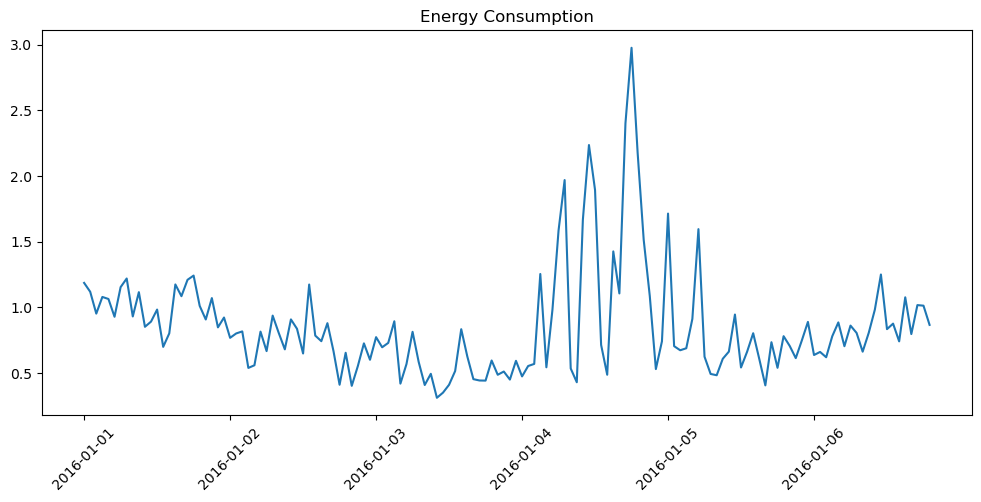

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df_hourly['House overall [kW]'])
plt.xticks(df_hourly.index[::24], rotation=45)
plt.title("Energy Consumption")
plt.show()

In [9]:
df_hourly['lag_1'] = df_hourly['House overall [kW]'].shift(1)
df_hourly['lag_24'] = df_hourly['House overall [kW]'].shift(24)

df_hourly.dropna(inplace=True)

df_hourly.head()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability,lag_1,lag_24
time,,,,,,,,,,,,,,,,,,,,,
2016-01-02 05:00:00,0.769182,0.101225,0.769182,0.040349,0.016614,0.284010,0.063675,0.047043,0.018245,0.014075,...,9.681806,18.462289,1021.614806,7.565600,158.336667,0.000031,9.547739,0.000806,0.923741,1.187276
2016-01-02 06:00:00,0.802421,0.097989,0.802421,0.038212,0.076890,0.244653,0.054336,0.049349,0.029338,0.013822,...,9.847511,31.746150,1021.771722,4.425939,225.942778,0.000000,18.253272,0.000000,0.769182,1.119695
2016-01-02 07:00:00,0.817993,0.101738,0.817993,0.032302,0.106774,0.188539,0.048856,0.052091,0.028242,0.014283,...,9.453828,55.319061,1016.704467,5.572600,204.255000,0.001830,40.744239,0.068933,0.802421,0.953479
2016-01-02 08:00:00,0.539962,0.075463,0.539962,0.016072,0.042160,0.077430,0.090934,0.056000,0.032417,0.013648,...,9.790800,46.612383,1018.786072,7.861933,270.913889,0.001349,34.806633,0.053994,0.817993,1.080323
2016-01-02 09:00:00,0.560249,0.106602,0.560249,0.016562,0.085404,0.091376,0.079564,0.053510,0.027133,0.013937,...,8.385506,41.338972,1016.920111,7.802561,69.343333,0.006191,31.541628,0.214117,0.539962,1.064834


In [10]:
X = df_hourly.drop(columns=['House overall [kW]'])
y = df_hourly['House overall [kW]']

split = int(0.8 * len(df_hourly))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(92, 29)
(24, 29)
(92,)
(24,)


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Linear RMSE:", rmse)

Linear RMSE: 2.920870498267011e-14


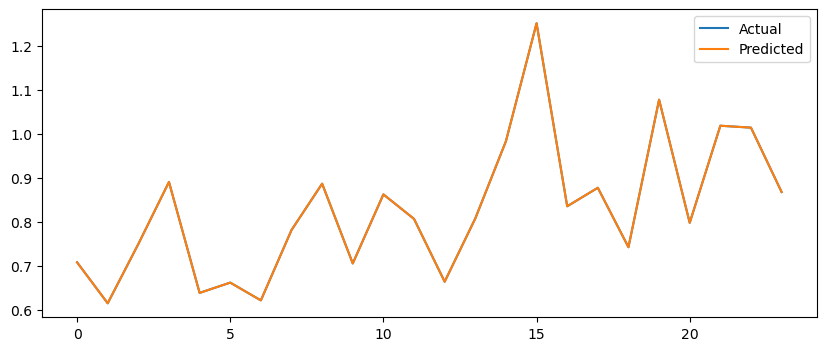

In [12]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

In [13]:
from scipy.stats import zscore

df_hourly['z'] = zscore(df_hourly['House overall [kW]'])

print("Anomalies:", len(df_hourly[np.abs(df_hourly['z']) > 3]))

Anomalies: 4


In [16]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

data = df_hourly[['House overall [kW]']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

X, y = [], []

for i in range(len(data_scaled) - 24):
    X.append(data_scaled[i:i+24])
    y.append(data_scaled[i+24])

X = np.array(X)
y = np.array(y)

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(73, 24, 1)
(19, 24, 1)
(73, 1)
(19, 1)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')

print("Model ready")

Model ready


In [19]:
history = lstm.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0793
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0578
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0441
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0363
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0361


In [20]:
y_pred_lstm = lstm.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_lstm)

from sklearn.metrics import mean_squared_error
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print("LSTM RMSE:", rmse_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
LSTM RMSE: 0.1648252173178582


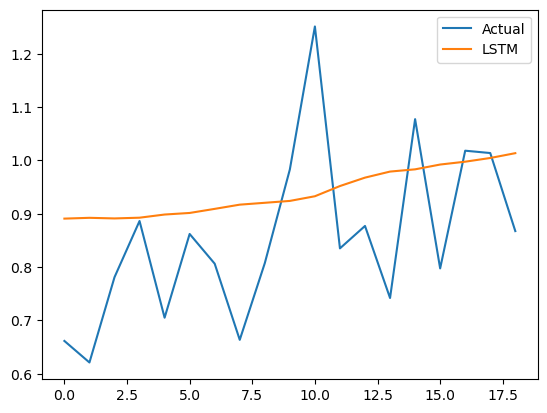

In [21]:
import matplotlib.pyplot as plt

plt.plot(y_test_inv[:100], label='Actual')
plt.plot(y_pred_inv[:100], label='LSTM')
plt.legend()
plt.show()

In [22]:
def predict_next(seq):
    s = scaler.transform(seq)
    s = s.reshape(1, s.shape[0], 1)
    return scaler.inverse_transform(lstm.predict(s))

In [23]:
sample = df_hourly[['House overall [kW]']].values[-24:]

print("Next Prediction:", predict_next(sample))

print("Linear RMSE:", rmse)
print("LSTM RMSE:", rmse_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
Next Prediction: [[1.0188472]]
Linear RMSE: 2.920870498267011e-14
LSTM RMSE: 0.1648252173178582
